# Multimodal AI Model Exploration Notebook

This notebook documents the exploration and testing of AI models across **6 modalities** before building the Streamlit application.

Each section tests a specific modality using the selected provider and model, validating that the API integration works correctly.

## 1. Assignment Objective

**Goal:** Explore and validate multiple AI models for the following modalities:

| # | Modality | Purpose |
|---|----------|---------|
| 1 | Text → Text | Generate text from prompts |
| 2 | Text → Image | Generate images from descriptions |
| 3 | Image → Text | Analyze/describe uploaded images |
| 4 | Audio → Text | Transcribe audio files |
| 5 | Text → Audio | Convert text to speech |
| 6 | Video → Text | Summarize video content |

**Text → Video is intentionally excluded.**

This notebook serves as proof-of-concept testing before integrating into the Streamlit app.

## 2. API Key Setup

Load API keys from the `.env` file located in the project root. Keys are never printed or exposed.

In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from the project root .env file
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), ".env"))

# Verify keys are loaded (without printing actual values)
gemini_key = os.getenv("GEMINI_API_KEY")
hf_token = os.getenv("HF_TOKEN")
openrouter_key = os.getenv("OPENROUTER_API_KEY")

print(f"GEMINI_API_KEY: {'Loaded' if gemini_key else 'Missing'}")
print(f"HF_TOKEN:       {'Loaded' if hf_token else 'Missing'}")
print(f"OPENROUTER_API_KEY: {'Loaded' if openrouter_key else 'Missing'}")

GEMINI_API_KEY: Loaded
HF_TOKEN:       Loaded
OPENROUTER_API_KEY: Loaded


## 3. Text → Text (OpenRouter)

Test text generation using the OpenRouter API with a free model.

In [4]:
import requests

# OpenRouter text generation test
url = "https://openrouter.ai/api/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {openrouter_key}",
    "Content-Type": "application/json",
}
payload = {
    "model": "openrouter/free",
    "messages": [{"role": "user", "content": "Explain what multimodal AI is in 3 sentences."}],
    "temperature": 0.7,
}

response = requests.post(url, headers=headers, json=payload, timeout=60)
if response.status_code == 200:
    result = response.json()["choices"][0]["message"]["content"]
    print("Text → Text Response:\n")
    print(result)
else:
    print(f"Request failed with status {response.status_code}")

Text → Text Response:

Multimodal AI refers to systems that can process and understand multiple types of data—such as text, images, audio, video, or sensor signals—within a single model. By integrating these diverse modalities, the AI can capture richer context and relationships (e.g., linking a spoken description to a visual scene) that single‑modal models miss. This enables more versatile applications like visual question answering, caption generation, robot perception, and cross‑modal retrieval.


## 4. Text → Image (Hugging Face)

Test image generation using Hugging Face's FLUX.1-schnell model.

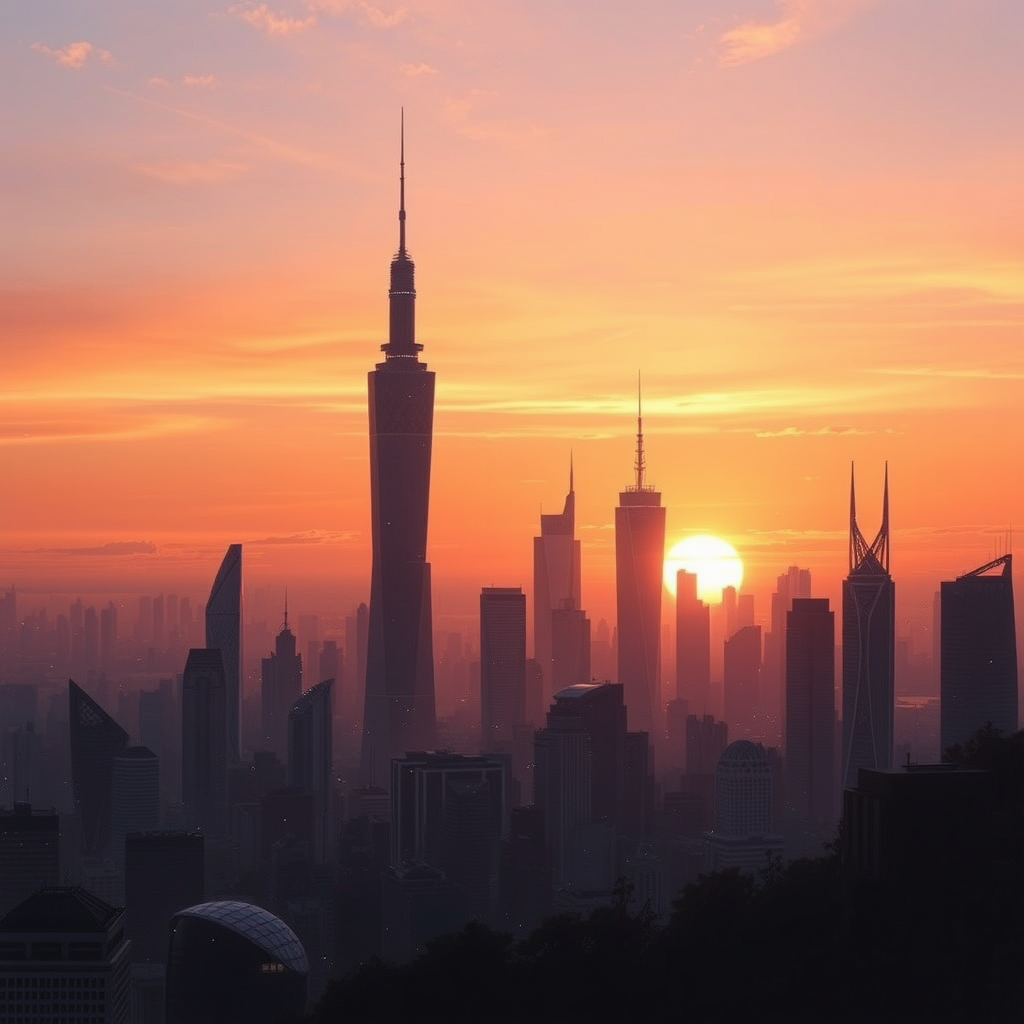

In [5]:
from huggingface_hub import InferenceClient
from IPython.display import display, Image as IPImage
from io import BytesIO

# Hugging Face image generation test
client = InferenceClient(token=hf_token)
image = client.text_to_image(
    "A futuristic city skyline at sunset, digital art style",
    model="black-forest-labs/FLUX.1-schnell"
)

# Display the generated image
buffer = BytesIO()
image.save(buffer, format="PNG")
display(IPImage(data=buffer.getvalue()))

## 5. Image → Text (OpenRouter Vision)

Test image analysis using OpenRouter with a vision-capable model. We use a sample image for this test.

In [20]:
import base64
from pathlib import Path

# Re-use the image generated in section 4
image_bytes = buffer.getvalue()
base64_image = base64.b64encode(image_bytes).decode("utf-8")
data_url = f"data:image/png;base64,{base64_image}"

result_text = None
provider_used = None

# --- Attempt 1: OpenRouter Vision ---
url = "https://openrouter.ai/api/v1/chat/completions"
headers = {
    "Authorization": f"Bearer {openrouter_key}",
    "Content-Type": "application/json",
}
payload = {
    "model": "openrouter/free",
    "messages": [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in detail."},
                {"type": "image_url", "image_url": {"url": data_url}},
            ],
        }
    ],
    "temperature": 0.3,
}

response = requests.post(url, headers=headers, json=payload, timeout=60)
if response.status_code == 200:
    result_text = response.json()["choices"][0]["message"]["content"]
    provider_used = "OpenRouter"
else:
    print(f"OpenRouter unavailable ({response.status_code}).")

# --- Attempt 2: Gemini ---
if not result_text:
    try:
        from google import genai

        temp_img = Path("../app/temp/vision_test.png")
        temp_img.parent.mkdir(parents=True, exist_ok=True)
        temp_img.write_bytes(image_bytes)

        gemini_client = genai.Client(api_key=gemini_key)
        uploaded = gemini_client.files.upload(file=str(temp_img))
        gemini_resp = gemini_client.models.generate_content(
            model="gemini-2.0-flash",
            contents=["Describe this image in detail.", uploaded],
        )
        result_text = gemini_resp.text
        provider_used = "Gemini"
        temp_img.unlink(missing_ok=True)
    except Exception as e:
        print(f"Gemini unavailable ({type(e).__name__}).")

# --- Attempt 3: Hugging Face BLIP ---
if not result_text:
    try:
        temp_img = Path("../app/temp/vision_test.png")
        temp_img.parent.mkdir(parents=True, exist_ok=True)
        temp_img.write_bytes(image_bytes)

        hf_client = InferenceClient(token=hf_token)
        hf_result = hf_client.image_to_text(
            str(temp_img), model="Salesforce/blip-image-captioning-large"
        )
        if hasattr(hf_result, "generated_text"):
            result_text = hf_result.generated_text
        elif isinstance(hf_result, dict):
            result_text = hf_result.get("generated_text", str(hf_result))
        else:
            result_text = str(hf_result)
        provider_used = "HF BLIP"
        temp_img.unlink(missing_ok=True)
    except Exception as e:
        print(f"HF BLIP also failed ({type(e).__name__}: {e})")

# --- Output ---
if result_text:
    print(f"Image → Text Response ({provider_used}):\n")
    print(result_text)
else:
    print("All providers exhausted. Try again later when quotas reset.")

OpenRouter unavailable (429).
Gemini unavailable (ClientError).
HF BLIP also failed (StopIteration: )
All providers exhausted. Try again later when quotas reset.


## 6. Audio → Text (Hugging Face Whisper)

Test audio transcription using Hugging Face's Whisper model. 

> **Note:** Place a sample `.wav` or `.mp3` file at `../app/assets/sample_inputs/sample_audio.wav` to run this cell, or update the path below.

In [12]:
# Hugging Face Whisper transcription test
audio_path = "../app/assets/sample_inputs/sampleAudio.wav"

if os.path.exists(audio_path):
    client = InferenceClient(token=hf_token)
    result = client.automatic_speech_recognition(
        audio_path,
        model="openai/whisper-large-v3"
    )

    # Extract text from result
    if isinstance(result, dict) and "text" in result:
        text = result["text"]
    elif hasattr(result, "text"):
        text = result.text
    else:
        text = str(result)

    print("Audio → Text Transcription:\n")
    print(text)
else:
    print(f"Sample audio file not found at: {audio_path}")
    print("Place a .wav or .mp3 file there and re-run this cell.")

Audio → Text Transcription:

 Welcome to my multimodal AI project built using Streamlit.


## 7. Text → Audio (Hugging Face TTS)

Test text-to-speech using Hugging Face's MMS-TTS model with a local pyttsx3 fallback.

In [30]:
%pip install pyttsx3 pywin32 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from IPython.display import Audio
import pyttsx3

# Hugging Face TTS test (with offline fallback)
tts_url = "https://api-inference.huggingface.co/models/facebook/mms-tts-eng"
tts_headers = {"Authorization": f"Bearer {hf_token}"}
tts_payload = {"inputs": "Hello! This is a test of text to speech generation."}

try:
    tts_response = requests.post(tts_url, headers=tts_headers, json=tts_payload, timeout=30)
    content_type = tts_response.headers.get("content-type", "")

    if tts_response.status_code == 200 and content_type.startswith("audio"):
        print("Text → Audio (HF TTS) successful")
        display(Audio(data=tts_response.content, autoplay=False))
    else:
        raise ConnectionError("Non-audio response from HF")

except Exception as e:
    print(f"HF TTS unavailable ({type(e).__name__}). Using local pyttsx3 fallback...\n")
    engine = pyttsx3.init()
    engine.say("Hello! This is a local fallback test.")
    engine.runAndWait()
    print("Text → Audio (pyttsx3 offline) successful")

HF TTS unavailable (ConnectionError). Using local pyttsx3 fallback...



ModuleNotFoundError: No module named 'pywintypes'

## 8. Video → Text (Frame Extraction + OpenRouter)

Test video summarization by extracting frames with OpenCV and describing them with OpenRouter.

> **Note:** Place a sample `.mp4` file at `../app/assets/sample_inputs/sample_video.mp4` to run this cell, or update the path below.

In [26]:
# %pip install opencv-python

import cv2

video_path = "../app/assets/sample_inputs/sampleVideo.mp4"
temp_dir = Path("../app/temp")
temp_dir.mkdir(parents=True, exist_ok=True)

if os.path.exists(video_path):
    # Extract 3 frames for quick testing
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    frame_indexes = [int(total_frames / 3 * i) for i in range(3)]
    captions = []

    for idx, frame_idx in enumerate(frame_indexes):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        success, frame = cap.read()
        if not success:
            continue

        # Save frame temporarily
        frame_path = temp_dir / f"test_frame_{idx}.jpg"
        cv2.imwrite(str(frame_path), frame)

        # Read and encode for OpenRouter
        with open(frame_path, "rb") as f:
            b64 = base64.b64encode(f.read()).decode("utf-8")

        # Describe the frame
        payload = {
            "model": "openrouter/free",
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": "Briefly describe this video frame."},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
                    ],
                }
            ],
            "temperature": 0.3,
        }
        resp = requests.post(url, headers=headers, json=payload, timeout=60)
        if resp.status_code == 200:
            caption = resp.json()["choices"][0]["message"]["content"]
            captions.append(caption)
            print(f"Frame {idx + 1}: {caption[:100]}...")

    cap.release()

    if captions:
        print(f"\nVideo → Text: Successfully described {len(captions)} frames")
    else:
        print("Could not describe any frames")
else:
    print(f"Sample video not found at: {video_path}")
    print("Place a .mp4 file there and re-run this cell.")

Total frames in video: 359
Could not describe any frames
